# Solve the BioHeat equation using finite differences

The OptimUS library provides a numerical algorith for solving the BioHeat equation. This can be useful for predicting temperatures in high frequency simulations. This notebook provides insight on how to use the BioHeat class and the methods associated.

## Import the OptimUS library

Load the OptimUS library.

In [1]:
import sys
sys.path.append('..')

In [2]:
import optimus

## Calculate the incident presure field

For completeness, we include a way to calculate the incident presure field. More information can be find in the notebook $\textit{"Array source simulation"}$. We start by selecting the parameters. In this notebook, a bowl source will be used, but any source scheme works. The parameter to select are the wave frequency in Hz, radii in meters, location of the source in a 3 dimensional tuple (meters) and velocity in meters per second.It is important to note that the routine only works with 3 dimensional arrays.

In [3]:
frequency = 500e3
radius_of_curvature = 0.064
radius = radius_of_curvature / 2
location = (0, 0, 0)
velocity = 0.198126
source = optimus.source.create_bowl(frequency, outer_radius=radius, radius_of_curvature=radius_of_curvature, 
                                    location=location, source_axis=(0, 0, 1), velocity=velocity)

Finally, we select the material of propagation and the limits and steps of the array.

In [4]:
material = optimus.material.load_material('water')

Nx = 51
Ny = 51
Nz = 101

xmin, xmax, ymin, ymax, zmin, zmax = [-0.03, 0.03, -0.03, 0.03, 0, 0.12]

delta_x = (xmax - xmin) / Nx
delta_y = (ymax - ymin) / Ny
delta_z = (zmax - zmin) / Nz

Where `Nx`, `Ny` and `Nz` represent the number of points on the x, y and z direction of the grid, and `delta_x`, `delta_y` and `delta_z` represents the distance (in meters) of two grid points in the x, y and z direction. Lastly, the field is calculated and stored in an array.

**Disclaimer**: the following calculation may take more than an hour, depending on the computing resources.

In [5]:
%%time

import numpy as np
from optimus.source.transducers import transducer_field

field = []

for layer in range(Nz):
    zval = layer * delta_z 
    plot_grid = np.mgrid[xmin:xmax:Nx * 1j, ymin:ymax:Ny * 1j]
    points = np.vstack((plot_grid[0].ravel(),
                        plot_grid[1].ravel(),
                        zval*np.ones(plot_grid[0].size)))
    
    inc_field = transducer_field(source, material, points, verbose=False)
    incident_pressure = inc_field.pressure.reshape([Nx, Ny])
    
    incident_pressure_plot = optimus.postprocess.common.array_to_imshow(incident_pressure)
    field.append(incident_pressure_plot)
    
field = np.array(field)

CPU times: user 8h 21min 35s, sys: 1.61 s, total: 8h 21min 37s
Wall time: 1h 4min 11s


In [6]:
field = np.abs(field)

## Create the BioHeat object

Given the pressure field, the BioHeat object can be created. The arguments are the numpy ndarray containing the incident pressure field calculated previously, the wave frequency in Hz, limits of the simulation with form (`xmin`, `xmax`, `ymin`, `ymax`, `zmin`, `zmax`) in meters, the material of propagation (an `optimus.material` object) and the ambient temperature which is by default 37 $[^\circ C]$.

In [7]:
limits = (xmin, xmax, ymin, ymax, zmin, zmax)

In [8]:
from optimus.postprocess import BioHeat

simulation = BioHeat(field, limits, material, frequency, ambient_temperature = 37)

The heat deposition of the field in W/m$^3$ is immediately computed and store in the heat_deposition attribute. This is done by using the approximation $Q\approx\alpha_0 f\frac{p\bar{p}}{c_0\rho_0}$ where
- $\alpha_0$ is the attenuation coefficient in m$^{-1}$.
- $f$ is the frequency in Hz.
- $p$ is the incident pressure field in Pa.
- $c_0$ is the speed of sound in m/s.
- $\rho_0$ is the density in kg/m$^3$.

In [9]:
np.max(simulation.heat_deposition)

251424.15734690227

## Run the simulation

The simulation of the temperature can be calculated with the `calculate_temperature` method. This method iteratively calls another method that solves the equation using finite differences. Specifically, the equation to solve is

$$
\rho_tC_t\frac{\partial T}{\partial t}=k_t\cdot \nabla^2T+Q
$$

where
- $\rho_t$ is the density in kg/m$^3$
- $C_t$ is the heat capacity in J/kg/°C
- $k_t$ is the thermal conductivity in W/m/°C
- $Q$ is the heat deposition in W/m$^3$

The finite difference method in 3 dimensions gives the aproximation

$$
T_{x,y,z}^{t+1} = AT_{x,y,x}^t + B(T_{x-1,y,z}^t + T_{x+1,y,z}^t) + C(T_{x,y-1,z}^t + T_{x,y+1,z}^t) + D(T_{x,y,z-1}^t + T_{x,y,z+1}^t) + EQ_{x,y,z}
$$

where $T_{x,y,z}^{t}$ is the temperature at the point $(x,y,z)$ at time $t$ and

$$
\begin{align*}
    A &= 1 -2\frac{k_t\Delta t}{\rho_tC_t}\left(\frac{1}{\Delta x^2}+\frac{1}{\Delta y^2}+\frac{1}{\Delta z^2}\right) \\
    B &= \frac{k_t\Delta t}{\rho_tC_t}\left(\frac{1}{\Delta x^2}\right)\\
    C &= \frac{k_t\Delta t}{\rho_tC_t}\left(\frac{1}{\Delta y^2}\right)\\
    D &= \frac{k_t\Delta t}{\rho_tC_t}\left(\frac{1}{\Delta z^2}\right)\\
    E &= \frac{\Delta t}{\rho_tC_t}
\end{align*}
$$

where $\Delta x$, $\Delta y$, $\Delta z$ and $\Delta t$ are the distances between 2 grid points in the $x,y,z$ and time direction.

The method takes as inputs the time duration of the simulation in seconds, `Nt` (the number of grid points of time), `ramp_function` which can take the values "continuous", "rectangular" or "turk", `period_duration` in seconds (the amount of time for which the source is on), `period_repetition_interval` in seconds (duration of each pulse) and the `ramp_duration` in seconds (only applies in the "turk" ramp scheme). By default, the settings are `Nt=int(1e3)`, `period_duration=2e-3`, `period_repetition_interval=4e-3`, `ramp_duration=0` and `ramp_function="continuous"`.

In [10]:
simulation.calculate_temperature(time=30, Nt=100)

In [11]:
np.max(simulation.temperature)

37.604492371888135

## Plot the results

Due to memory limitations, the library only stores the last temperature field, which can be accessed using the `.temperature`attribute. The method `plot_temperature` plots this array, taking as arguments the `layer` for which the slice is taken and the `axis` of the slice (0, 1 or 2) and a list (`colormap_limits`) containing the colormap limits (by default is the maximum and minimum temperature of the slice).

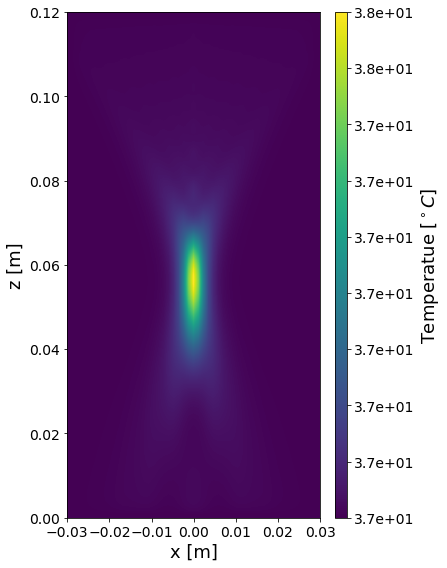

In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

simulation.plot_temperature(25, axis= 1, colormap_limits = [37, 37.6])

However, the historial of the maximum temperature in the whole array is store in the attribute `max_temperature`.

In [13]:
simulation.max_temperatures[-1]

37.60194210124902

The array can be plot using the attribute `time_domain` for the x axis.

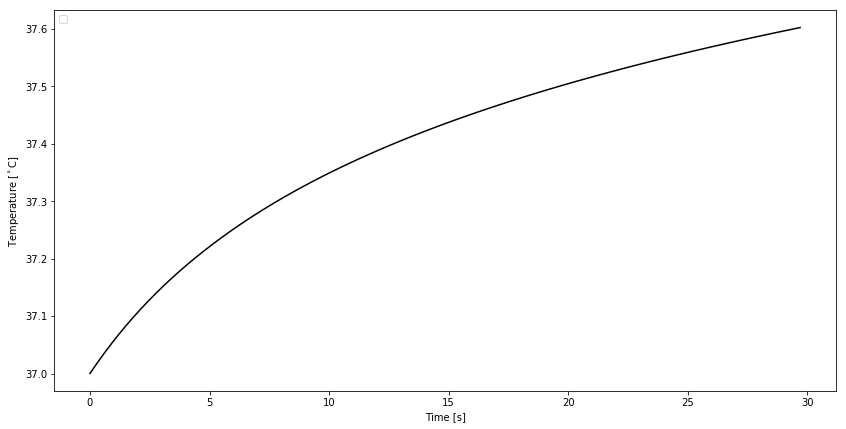

In [14]:
%matplotlib inline

fig = plt.figure(figsize = (14,7))

plt.plot(simulation.time_domain, simulation.max_temperatures, c='black')

plt.legend(loc = 'upper left')
plt.xlabel('Time [s]')
plt.ylabel('Temperature [$^\circ$C]')
plt.show()

## Validation

To validate the simulation, we are going to compare the results with the HITU simulator ((https://github.com/jsoneson/HITU_Simulator). The parameters selected in `WAKZK.m` are

```Matlab
%% Transducer %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Tx.f = 5e5;		% frequency (Hz) 
Tx.a1 = 0;		% inner radius (cm) 
Tx.a2 = 3.2;		% outer radius (cm) 
Tx.d = 6.4;		% geometric focus (cm) [= Inf if planar array] 
Tx.P = 100;		% total acoustic power (W) 

%% Computational Grid %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
Grid.Z = 12;		% max axial distance (cm)
Grid.KK = 1;		% max number of harmonics in simulation (use power of 2) 
ppw_r = 15;		% grid resolution in r-direction; points per wavelength
ppw_z = 10;		% and z-direction

%% Layered media %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
II = 1;			% number of layers

% material 1 parameters:
Layer(1).z = 0;		% material transition distance (cm)	
Layer(1).c = 1482;	% small-signal sound speed (m/s)
Layer(1).rho = 994;	% mass density (kg/m^3)
Layer(1).alpha = 0.217;	% attenuation at 1MHz (dB/m)
Layer(1).fraction = 1;	% fraction of attenuation due to absorption	
Layer(1).eta = 1;	% exponent in attenuation power law
Layer(1).beta = 3.5;	% nonlinear parameter 
Layer(1).Cp = 4178;	% heat capacity (J/kg/K)
Layer(1).kappa = 0.6;	% thermal conductivity (W/m/K)
Layer(1).w = 0;		% perfusion rate (kg/m^3/s)
```
and in the file `BHT.m`, the following parameters were selected

```Matlab
% set heating and cooling durations:
t_h = 3;	% heating time (s)
t_c = 0;	% cooling time (s)
```
We include the `.m` files in the data folder. 
The results are store in the file `bioheat_simulation_with_hitu.csv`.

In [15]:
import pandas as pd

df = pd.read_csv('Data/bioheat_simulation_with_hitu.csv')
hitu = df['temperatures'].to_numpy()

Next, the equivalent `BioHeat` object is created. The same simulation is computed.

In [16]:
validation_simulation = BioHeat(field, limits, material, frequency, ambient_temperature = 37)

In [17]:
validation_simulation.calculate_temperature(time=3, Nt=int(3e2))

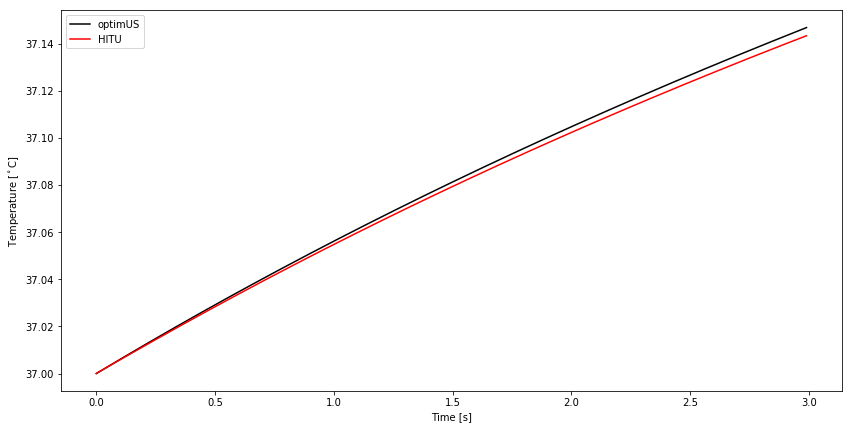

In [18]:
%matplotlib inline

fig = plt.figure(figsize = (14,7))

plt.plot(validation_simulation.time_domain, validation_simulation.max_temperatures, 
         c='black', label = 'optimUS')
plt.plot(validation_simulation.time_domain, hitu, c='red', label = 'HITU')

plt.legend(loc = 'upper left')
plt.xlabel('Time [s]')
plt.ylabel('Temperature [$^\circ$C]')
plt.show()